# 02 — Model A: transfer-learning baseline

Train MobileNetV2 on original training images transformed to 128×128. A stratified validation subset is derived only from the persisted training manifest. The reserved test manifest is intentionally not loaded in this notebook. Model selection uses validation F1.

## Local setup

Run this notebook from the local repository with the project virtual environment selected as the Jupyter kernel. It uses `data/raw/` and writes resumable checkpoints under `artifacts/checkpoints/model_a/`.

In [ ]:
import sys
from pathlib import Path

start_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (start_directory, *start_directory.parents)
        if (candidate / 'pyproject.toml').is_file()
        and (candidate / 'src' / 'applied_ai_midterm').is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    codex_workspace = Path.home() / 'Documents' / 'Codex'
    if codex_workspace.is_dir():
        PROJECT_ROOT = next(
            (
                config_file.parent
                for config_file in codex_workspace.rglob('pyproject.toml')
                if config_file.parent.name == 'MLawson-Applied-AI-Midterm'
                and (config_file.parent / 'src' / 'applied_ai_midterm').is_dir()
            ),
            None,
        )
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Open this notebook from inside the MLawson-Applied-AI-Midterm repository.'
    )

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Local project root: {PROJECT_ROOT}')
print(f'Python kernel: {sys.executable}')

In [8]:
import json
from dataclasses import asdict

import matplotlib.pyplot as plt
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

from applied_ai_midterm.classifier import create_binary_mobilenet
from applied_ai_midterm.config import load_config
from applied_ai_midterm.datasets import create_classifier_dataloaders
from applied_ai_midterm.training import (
    fit_classifier,
    seed_everything,
    select_device,
)

## Reproducible paths and hyperparameters

Only `data/splits/train.csv` is supplied to the loader. The validation subset is stratified with the project seed and cannot contain reserved test records.

In [9]:
config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
seed_everything(config.random_seed)
device = select_device()

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
CHECKPOINT_DIR = PROJECT_ROOT / 'artifacts' / 'checkpoints' / 'model_a'

TRAIN_MANIFEST = PROJECT_ROOT / 'data' / 'splits' / 'train.csv'
VALIDATION_RATIO = 0.20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

print(f'Device: {device}')
print(f'Raw data: {RAW_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')
if not RAW_DIR.is_dir():
    raise FileNotFoundError(
        f'Raw dataset missing at {RAW_DIR}. Run notebook 01 setup, then Run all again.'
    )
if not TRAIN_MANIFEST.is_file():
    raise FileNotFoundError(
        f'Training manifest missing at {TRAIN_MANIFEST}. Run notebook 01 first.'
    )

Device: mps
Raw data: <PROJECT_ROOT>/data/raw
Checkpoints: <PROJECT_ROOT>/artifacts/checkpoints/model_a


In [10]:
loaders = create_classifier_dataloaders(
    TRAIN_MANIFEST,
    RAW_DIR,
    image_size=config.high_resolution_size,
    batch_size=config.classifier_batch_size,
    validation_ratio=VALIDATION_RATIO,
    random_seed=config.random_seed,
    num_workers=config.num_workers,
)
print(f'Training examples: {loaders.train_size:,}')
print(f'Validation examples: {loaders.validation_size:,}')
print(f'Class mapping: {loaders.class_mapping}')

Training examples: 13,960
Validation examples: 3,491
Class mapping: {'cats': 0, 'dogs': 1}


## Initialize or resume Model A

`BCEWithLogitsLoss` consumes the model's single raw logit. Sigmoid is used only inside metric calculation. The latest checkpoint resumes all model, optimizer, scheduler, history, configuration, seed, class-mapping, and random-number-generator state.

In [11]:
model = create_binary_mobilenet(pretrained=True)
criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = StepLR(optimizer, step_size=7, gamma=0.1)
latest_checkpoint = CHECKPOINT_DIR / 'classifier_a_latest.pt'
resume_from = latest_checkpoint if latest_checkpoint.is_file() else None
resume_description = str(resume_from) if resume_from else 'none — starting epoch 1'
print(f'Resume checkpoint: {resume_description}')

Resume checkpoint: <PROJECT_ROOT>/artifacts/checkpoints/model_a/classifier_a_latest.pt


In [12]:
run_configuration = {
    **asdict(config),
    'architecture': 'mobilenet_v2',
    'pretrained_weights': 'MobileNet_V2_Weights.DEFAULT',
    'validation_ratio': VALIDATION_RATIO,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'scheduler': 'StepLR(step_size=7, gamma=0.1)',
}
history = fit_classifier(
    model,
    loaders.train,
    loaders.validation,
    optimizer,
    criterion,
    epochs=config.classifier_epochs,
    device=device,
    checkpoint_dir=CHECKPOINT_DIR,
    class_mapping=loaders.class_mapping,
    random_seed=config.random_seed,
    configuration=run_configuration,
    scheduler=scheduler,
    resume_from=resume_from,
)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
history_path = CHECKPOINT_DIR / 'classifier_a_history.json'
history_path.write_text(json.dumps(history, indent=2), encoding='utf-8')
print(f'History saved: {history_path}')
best_checkpoint = CHECKPOINT_DIR / 'classifier_a_best.pt'
print(f'Best checkpoint: {best_checkpoint}')

History saved: <PROJECT_ROOT>/artifacts/checkpoints/model_a/classifier_a_history.json
Best checkpoint: <PROJECT_ROOT>/artifacts/checkpoints/model_a/classifier_a_best.pt


## Training and validation history

These are development curves only. Final reserved-test evaluation belongs in the comparison phase after both classifiers are trained.

Final validation metrics:


{'accuracy': 0.9753652248639358,
 'precision': 0.9636668529904975,
 'recall': 0.9879656160458453,
 'f1': 0.9756649688737974,
 'roc_auc': 0.9963804291101724,
 'loss': 0.08492859567161333,
 'epoch': 20.0}

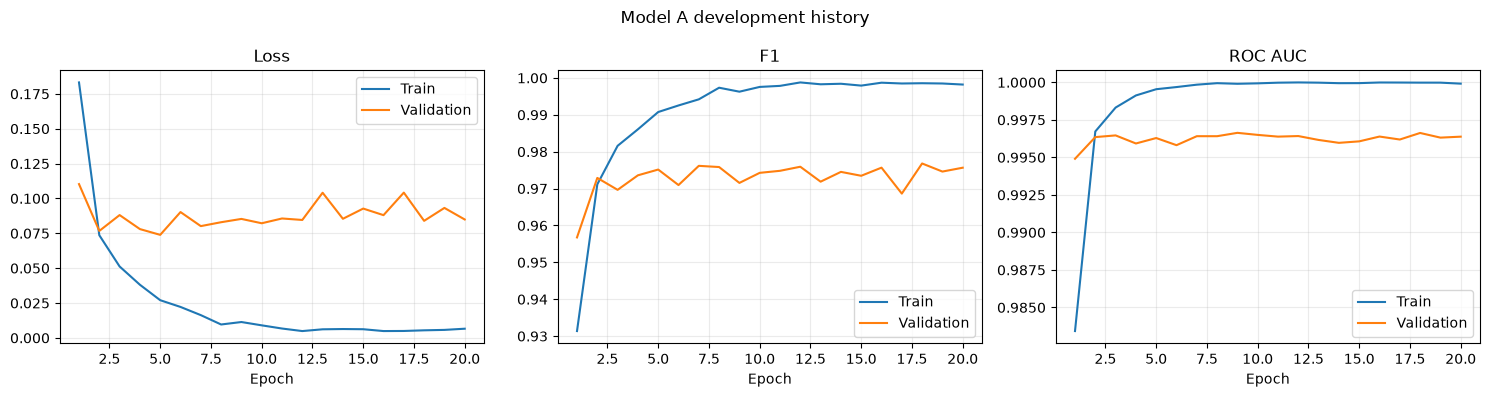

In [13]:
train_history = history['train']
validation_history = history['validation']
epochs = [int(row['epoch']) for row in train_history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for split_name, rows in (
    ('Train', train_history),
    ('Validation', validation_history),
):
    axes[0].plot(epochs, [row['loss'] for row in rows], label=split_name)
    axes[1].plot(epochs, [row['f1'] for row in rows], label=split_name)
    axes[2].plot(epochs, [row['roc_auc'] for row in rows], label=split_name)
for axis, title in zip(axes, ('Loss', 'F1', 'ROC AUC'), strict=True):
    axis.set_title(title)
    axis.set_xlabel('Epoch')
    axis.legend()
    axis.grid(alpha=0.25)
plt.suptitle('Model A development history')
plt.tight_layout()

print('Final validation metrics:')
validation_history[-1]